# Problem statement:
Machine Failure Prediction Using Machine Learning for Predictive Maintenance  

- In industrial environments, unexpected machine failures can lead to production downtime, increased operational costs, and safety risks. Traditional maintenance strategies such as reactive maintenance (repair after failure) or scheduled maintenance (fixed time intervals) are inefficient and costly.
The objective of this project is to develop a machine learning classification model that can predict whether a machine is likely to fail or not .

In [1]:
# all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb


# ml libraries
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline as sklpipeline
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [2]:
# dataset
data = pd.read_csv("C:\\Users\\rajka\\OneDrive\\Desktop\\Desktop_apps\\All Folders\\datasets\\predictive_maintenance_dataset.csv")
data


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


# basic analysis and check other factors


In [3]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
# Descriptive analysis 
data.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [5]:
# check duplicate columns 
data.duplicated().sum()

np.int64(0)

In [35]:
# seprate the numerical and categorical features
numerical  = [i for i in data.columns if not data[i].dtype == 'object' and i != 'Machine failure']

In [7]:
# check correlation of all features with the target feature
for i in data.columns:
    if i in numerical:
        print(i,data[i].corr(data['Machine failure']))

UDI -0.02289180554800691
Air temperature [K] 0.08255568978323986
Process temperature [K] 0.03594597332977694
Rotational speed [rpm] -0.0441875597343754
Torque [Nm] 0.19132077505949352
Tool wear [min] 0.1054482189195954
TWF 0.36290361100612745
HDF 0.5758001521562414
PWF 0.522812249626967
OSF 0.5310834511801947
RNF 0.004515993098786952


<Axes: xlabel='Machine failure'>

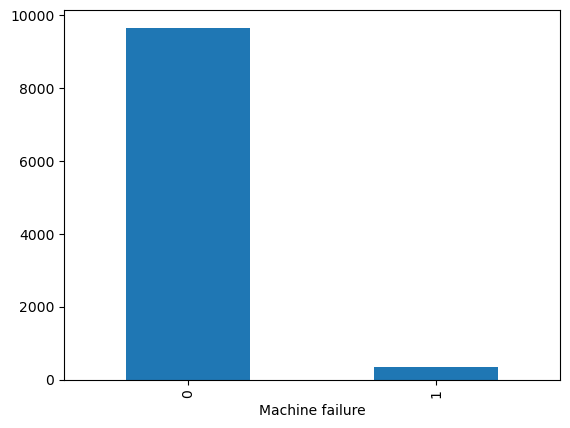

In [8]:
# check the distribution of the target feature - which tell us that data is highly imbalanced
data['Machine failure'].value_counts().plot(kind ='bar')

In [9]:
# check distribution of categorical feature
data['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

C:\Users\rajka\AppData\Local\Temp\ipykernel_2912\585419233.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(data['Torque [Nm]'])
C:\Users\rajka\AppData\Local\Temp\ipykernel_2912\585419233.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(data['Tool wear [min]'])
C:\Users\rajka\AppData\Local\T

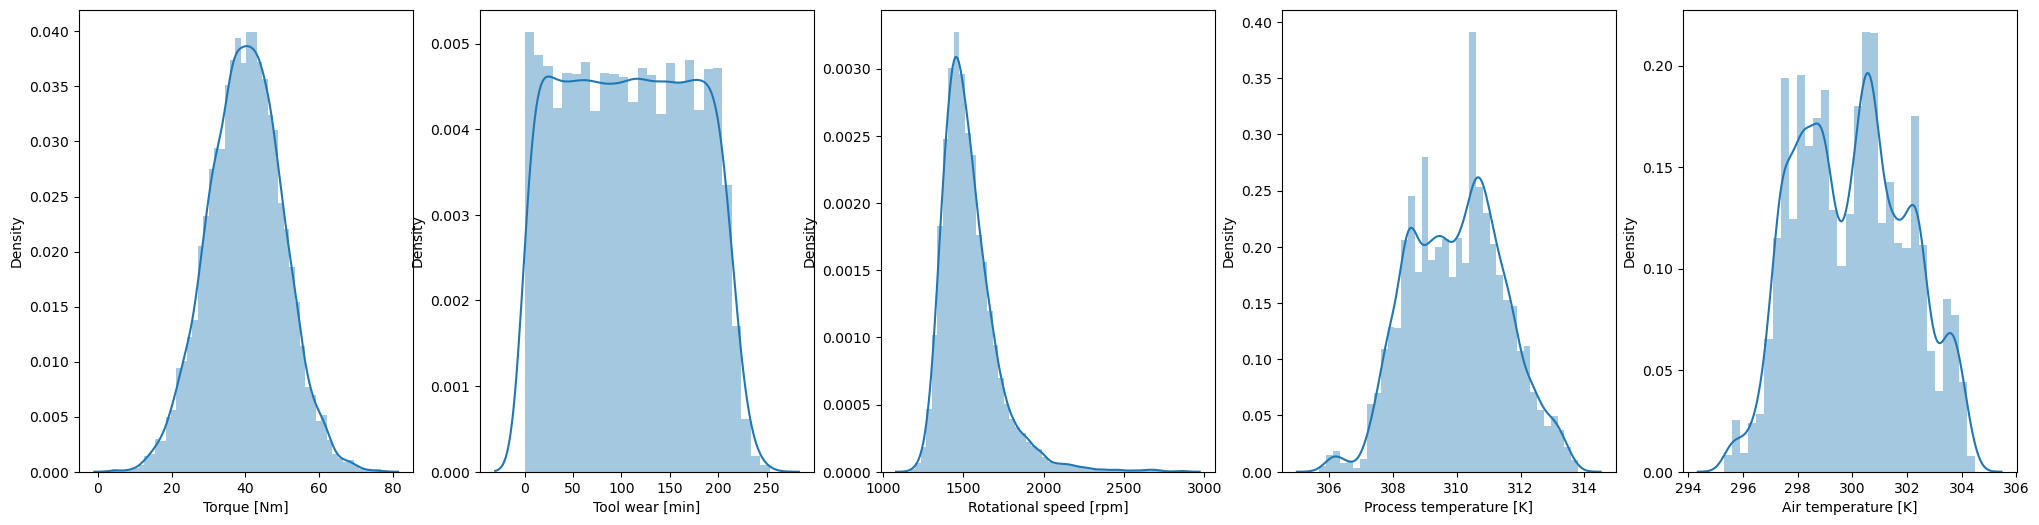

In [10]:
# visualize some columns distribution - most of the columns are normally distributed
plt.figure(figsize=(25,6))
plt.subplot(1,5,1)
sb.distplot(data['Torque [Nm]'])

plt.subplot(1,5,2)
sb.distplot(data['Tool wear [min]'])

plt.subplot(1,5,3)
sb.distplot(data['Rotational speed [rpm]'])

plt.subplot(1,5,4)
sb.distplot(data['Process temperature [K]'])

plt.subplot(1,5,5)
sb.distplot(data['Air temperature [K]'])


plt.show()

# Prepare data for models

In [51]:
# dataset
data = pd.read_csv("C:\\Users\\rajka\\OneDrive\\Desktop\\Desktop_apps\\All Folders\\datasets\\predictive_maintenance_dataset.csv")
data


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


### drop irrelevant features or other features  - these are the features which tell which kind of the failure happend when machine failed so they are not input features so we will drop them
TWF → Tool Wear Failure
→ Machine failed because the tool became too worn out.

HDF → Heat Dissipation Failure
→ Machine failed because temperature got too high (cooling couldn’t handle heat).

PWF → Power Failure
→ Machine failed due to abnormal power usage (too much or too little power).

OSF → Overstrain Failure
→ Machine failed because of excessive mechanical stress/overload.

RNF → Random Failure
→ Failure happened randomly (not linked to measured conditions).

In [52]:
data.drop(columns =['UDI','Product ID','TWF','HDF','PWF','OSF','RNF'],axis = 1,inplace = True)

### Encoding the features using maping and oversampling the minority class usins smote

In [53]:
# simply map values for the type feature if not used in pipeline ---> don't execute this cell if pipeline will be created
data['Type'] = data['Type'].map({'L':0,'M':1,'H':2})

In [54]:
data

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,298.1,308.6,1551,42.8,0,0
1,0,298.2,308.7,1408,46.3,3,0
2,0,298.1,308.5,1498,49.4,5,0
3,0,298.2,308.6,1433,39.5,7,0
4,0,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...
9995,1,298.8,308.4,1604,29.5,14,0
9996,2,298.9,308.4,1632,31.8,17,0
9997,1,299.0,308.6,1645,33.4,22,0
9998,2,299.0,308.7,1408,48.5,25,0


In [55]:
# input and target feature selecting
X = data.drop('Machine failure', axis = 1)
y = data['Machine failure']

In [56]:
# split training and testing data
x_train,x_test,y_train,y_test =train_test_split(X, y, test_size =0.2,random_state = 42, stratify =y)

In [38]:
scaler = StandardScaler()
encoder = OrdinalEncoder(categories = [['L','M','H']])  ## specially for the input features 

# ordinal encoder --> for the input features 
# label enoder --> for the target features
# one hot encoder ---> for the input 


In [57]:
# only used when not included in pipleline
smote = SMOTE(random_state =42,sampling_strategy = 0.5)
x_train_smote ,y_train_smote = smote.fit_resample(x_train,y_train)

#### sklearn pipeline

In [39]:
# make a column transformer to perform the different transformations collectively
preprocessing = ColumnTransformer(transformers= [
    ('numeric',scaler,numerical),  #for numerical features
    ('categorical',encoder,['Type'])  # for type feature --> perform ordinal encoding
])

### Models

In [69]:
model1 = LogisticRegression(penalty = 'l2',solver ='lbfgs',C =1.5)
model2 = DecisionTreeClassifier(max_depth = 5,criterion = 'gini', random_state =42,min_samples_split =10,min_samples_leaf =5)
model3 = RandomForestClassifier(n_estimators = 200,random_state =42,min_samples_split =25,min_samples_leaf =13)
model4 = SVC(kernel ='rbf', C = 1, gamma ='scale')
model5 = DecisionTreeClassifier(class_weight ='balanced',max_depth = 5,criterion = 'gini', random_state =42,min_samples_split =10,min_samples_leaf =5)
model6 = RandomForestClassifier(class_weight='balanced',n_estimators = 200,random_state =42,min_samples_split = 25,min_samples_leaf =13)
log2 = LogisticRegression(class_weight ='balanced',penalty = 'l2',solver ='lbfgs',C =1)
svm2 =SVC(class_weight = 'balanced',kernel ='rbf', C = 1, gamma ='scale')


### imblearn pipeline to include smote step in pipeline

In [41]:
# pipeline for svc 
svm_pipe= Pipeline([
    ('sklearn preprocessing',preprocessing),  # sklearn  include preprocessing
    ('smote',SMOTE(random_state =42,sampling_strategy =0.5)), # directly use smote in imblearn pipeline # sampling_strategy= 0.5 make syntetic darta of 50% of manority data
    ('model',model4)
])

svm_pipe.fit(x_train,y_train)
svm_train_pred = svm_pipe.predict(x_train)
svm_test_pred = svm_pipe.predict(x_test)

In [43]:
# svm pipeline without smote
svm_pipe2=sklpipeline([
    ('sklearn preprocessing',preprocessing),  # sklearn  include preprocessing
    ('model',svm2)
])

svm_pipe2.fit(x_train,y_train)
svm2_train_pred = svm_pipe2.predict(x_train)
svm2_test_pred = svm_pipe2.predict(x_test)

In [45]:
# Imbalance pipeline for logistic using smote
logistic_pipe= Pipeline([
    ('sklearn preprocessing',preprocessing),
    ('smote',SMOTE(random_state =42,sampling_strategy = 0.5)),
    ('model',model1)
])

logistic_pipe.fit(x_train,y_train)
log_train_pred = logistic_pipe.predict(x_train)
log_test_pred = logistic_pipe.predict(x_test)

In [46]:
# logistic pipleine without smote 
logistic_pipe2= sklpipeline([
    ('sklearn preprocessing',preprocessing),
    ('model',log2)
])

logistic_pipe2.fit(x_train,y_train)
log2_train_pred = logistic_pipe2.predict(x_train)
log2_test_pred = logistic_pipe2.predict(x_test)

In [58]:
# Decision Tree model
model2.fit(x_train_smote,y_train_smote)  #used simple unscaled datasets
dt_train_pred = model2.predict(x_train_smote)
dt_test_pred = model2.predict(x_test)


In [59]:
# Decision tree without smote
model5.fit(x_train,y_train)  #used simple unscaled datasets
dt2_train_pred = model5.predict(x_train)
dt2_test_pred = model5.predict(x_test)

In [70]:
# Random forest model
model3.fit(x_train_smote,y_train_smote)  #used simple unscaled datasets
rf_train_pred = model3.predict(x_train_smote)
rf_test_pred = model3.predict(x_test)

In [71]:
# another random forest without smote
model6.fit(x_train,y_train)  #used simple unscaled datasets
rf2_train_pred = model6.predict(x_train)
rf2_test_pred = model6.predict(x_test)

In [62]:
result = {}
def evaluate_model(model,y_train,y_test,y_train_pred,y_pred):
    model_name = model.__class__.__name__  ## to avoid the all estimators name and use only model name 
    print(f'\n{model_name} Evaluation\n')
    train_accuracy =accuracy_score(y_train,y_train_pred)
    test_accuracy =accuracy_score(y_test,y_pred)
    precision =precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1= f1_score(y_test,y_pred)
   
    # store the all metrices score in dictionary to use in dataframe later
    result[model_name] = {
        'Train_Accuracy' :train_accuracy,
        'Test_Accuracy': test_accuracy,
        'Precision': precision,
        'Recall': recall,
        'f1_score': f1,
    }

    print(f'\nname {model_name}')
    print(f'Train Accuracy: {train_accuracy}')
    print(f'Test Accuracy: {test_accuracy}')
    print(f'Precision score: {precision}')
    print(f'Recall score: {recall}')
    print(f'f1_score : {f1}')
    print('\nConfusion Matrix\n',confusion_matrix(y_test,y_pred))
    print('\n\nClassification Report\n',classification_report(y_test,y_pred))


In [63]:
print('Logistic regression pipeline')
evaluate_model(logistic_pipe,y_train,y_test,log_train_pred,log_test_pred)
print('logistec pipeline without SMOTE')
evaluate_model(logistic_pipe2,y_train,y_test,log2_train_pred,log2_test_pred)

print('SVM pipeline')
evaluate_model(svm_pipe,y_train,y_test,svm_train_pred,svm_test_pred)

print('SVM pipeline without smote')
evaluate_model(svm_pipe2,y_train,y_test,svm2_train_pred,svm2_test_pred)

Logistic regression pipeline

Pipeline Evaluation


name Pipeline
Train Accuracy: 0.898375
Test Accuracy: 0.904
Precision score: 0.22566371681415928
Recall score: 0.75
f1_score : 0.3469387755102041

Confusion Matrix
 [[1757  175]
 [  17   51]]


Classification Report
               precision    recall  f1-score   support

           0       0.99      0.91      0.95      1932
           1       0.23      0.75      0.35        68

    accuracy                           0.90      2000
   macro avg       0.61      0.83      0.65      2000
weighted avg       0.96      0.90      0.93      2000

logistec pipeline without SMOTE

Pipeline Evaluation


name Pipeline
Train Accuracy: 0.82125
Test Accuracy: 0.8205
Precision score: 0.13895781637717122
Recall score: 0.8235294117647058
f1_score : 0.23779193205944799

Confusion Matrix
 [[1585  347]
 [  12   56]]


Classification Report
               precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
        

In [64]:
evaluate_model(model2,y_train_smote,y_test,dt_train_pred,dt_test_pred)


DecisionTreeClassifier Evaluation


name DecisionTreeClassifier
Train Accuracy: 0.9365996722159924
Test Accuracy: 0.926
Precision score: 0.29591836734693877
Recall score: 0.8529411764705882
f1_score : 0.4393939393939394

Confusion Matrix
 [[1794  138]
 [  10   58]]


Classification Report
               precision    recall  f1-score   support

           0       0.99      0.93      0.96      1932
           1       0.30      0.85      0.44        68

    accuracy                           0.93      2000
   macro avg       0.65      0.89      0.70      2000
weighted avg       0.97      0.93      0.94      2000



In [72]:
evaluate_model(model3,y_train_smote,y_test,rf_train_pred,rf_test_pred)


RandomForestClassifier Evaluation


name RandomForestClassifier
Train Accuracy: 0.9698956266712672
Test Accuracy: 0.954
Precision score: 0.40625
Recall score: 0.7647058823529411
f1_score : 0.5306122448979592

Confusion Matrix
 [[1856   76]
 [  16   52]]


Classification Report
               precision    recall  f1-score   support

           0       0.99      0.96      0.98      1932
           1       0.41      0.76      0.53        68

    accuracy                           0.95      2000
   macro avg       0.70      0.86      0.75      2000
weighted avg       0.97      0.95      0.96      2000



In [66]:
evaluate_model(model5,y_train,y_test,dt2_train_pred,dt2_test_pred)


DecisionTreeClassifier Evaluation


name DecisionTreeClassifier
Train Accuracy: 0.9305
Test Accuracy: 0.9295
Precision score: 0.31088082901554404
Recall score: 0.8823529411764706
f1_score : 0.45977011494252873

Confusion Matrix
 [[1799  133]
 [   8   60]]


Classification Report
               precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.31      0.88      0.46        68

    accuracy                           0.93      2000
   macro avg       0.65      0.91      0.71      2000
weighted avg       0.97      0.93      0.95      2000



In [73]:
evaluate_model(model6,y_train,y_test,rf2_train_pred,rf2_test_pred)


RandomForestClassifier Evaluation


name RandomForestClassifier
Train Accuracy: 0.95975
Test Accuracy: 0.9535
Precision score: 0.4125874125874126
Recall score: 0.8676470588235294
f1_score : 0.5592417061611374

Confusion Matrix
 [[1848   84]
 [   9   59]]


Classification Report
               precision    recall  f1-score   support

           0       1.00      0.96      0.98      1932
           1       0.41      0.87      0.56        68

    accuracy                           0.95      2000
   macro avg       0.70      0.91      0.77      2000
weighted avg       0.98      0.95      0.96      2000



{'Pipeline': {'Train_Accuracy': 0.926,
  'Test_Accuracy': 0.9205,
  'Precision': np.float64(0.2903225806451613),
  'Recall': np.float64(0.9264705882352942),
  'f1_score': np.float64(0.4421052631578947)},
 'DecisionTreeClassifier': {'Train_Accuracy': 0.9305,
  'Test_Accuracy': 0.9295,
  'Precision': np.float64(0.31088082901554404),
  'Recall': np.float64(0.8823529411764706),
  'f1_score': np.float64(0.45977011494252873)},
 'RandomForestClassifier': {'Train_Accuracy': 0.95975,
  'Test_Accuracy': 0.9535,
  'Precision': np.float64(0.4125874125874126),
  'Recall': np.float64(0.8676470588235294),
  'f1_score': np.float64(0.5592417061611374)}}

# so from here we conclude sometime for imbalanced data
SMOTE - works well with linear models then class_weights ='balanced'
class_weights ='balanced' - hyperparameter works well with tree and ensemble model